In [1]:
pwd!

'/content'

In [2]:
#імпорт робочого файлу з google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
#зчитування csv файлу
conect_to_file = '/content/drive/My Drive/Colab/facebook_ads_data (2.0).csv'
ads = pd.read_csv(conect_to_file)
print(ads.head())

      ad_date campaign_name  total_spend  total_impressions  total_clicks  \
0  2022-11-05     Expansion         0.00                  0             0   
1  2022-11-01     Expansion         0.00                  0             0   
2  2022-10-31     Expansion       227.45               6054            58   
3  2022-10-30     Expansion       335.91              27562            69   
4  2022-10-29     Expansion       714.03              33358           115   

   total_value   cpc    cpm       ctr      romi  
0         0.00   NaN    NaN       NaN       NaN  
1         0.00   NaN    NaN       NaN       NaN  
2       191.87  3.92  37.57  0.009580  0.843570  
3       472.61  4.87  12.19  0.002503  1.406954  
4       680.34  6.21  21.41  0.003447  0.952817  


In [24]:
#видаляю порожні рядки
ads.dropna(axis=0, how='all')

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817
5,2022-10-28,Expansion,630.33,5522,121,590.00,5.21,114.15,0.021912,0.936018
6,2022-10-27,Expansion,359.63,45223,87,376.69,4.13,7.95,0.001924,1.047438
...,...,...,...,...,...,...,...,...,...,...
1489,2020-11-15,Discounts,6.98,12465,657,10.96,0.01,0.56,0.052708,1.570201
1490,2020-11-14,Discounts,7.27,5005,392,12.67,0.02,1.45,0.078322,1.742779
1491,2020-11-13,Discounts,6.36,11669,451,9.77,0.01,0.55,0.038649,1.536164
1492,2020-11-12,Discounts,23.00,10473,397,21.13,0.06,2.20,0.037907,0.918696


In [5]:
#імпорт бібліотек для візуалізацій
import matplotlib.pyplot as plt
import seaborn as sns

Зроби групування даних по дням та для згрупованих даних побудуй два графіки:

Графік з щоденною сумою витрат на рекламу в 2021 році;
Графік з щоденним ROMI в 2021 році.

In [6]:
#перетворення дати у формат datetime
ads['ad_date'] = pd.to_datetime(ads['ad_date'])
#відфільтровую дані за 2021 рік
year_2021= ads[(ads['ad_date'] >= '2021-01-01') & (ads['ad_date'] <= '2021-12-31')]
print(year_2021.head())

       ad_date campaign_name  total_spend  total_impressions  total_clicks  \
274 2021-12-31     Lookalike       143.19              24699           194   
275 2021-12-31        Trendy         8.82              25345            63   
276 2021-12-31     Wholesale        21.37               6705            24   
277 2021-12-30     Lookalike       227.56              44527           897   
278 2021-12-30        Trendy        31.92               8833            58   

     total_value   cpc   cpm       ctr      romi  
274       138.86  0.74  5.80  0.007855  0.969760  
275        16.32  0.14  0.35  0.002486  1.850340  
276        27.93  0.89  3.19  0.003579  1.306972  
277       243.02  0.25  5.11  0.020145  1.067938  
278        63.67  0.55  3.61  0.006566  1.994674  


In [7]:
#групую витрати на рекламу за 2021 рік
grouped_2021 = year_2021.groupby('ad_date')['total_spend'].sum().reset_index()
print(grouped_2021)

       ad_date  total_spend
0   2021-01-01         0.39
1   2021-01-02         7.74
2   2021-01-04        70.06
3   2021-01-05        81.15
4   2021-01-06       142.77
..         ...          ...
324 2021-12-27       478.31
325 2021-12-28       359.83
326 2021-12-29       163.25
327 2021-12-30       285.67
328 2021-12-31       173.38

[329 rows x 2 columns]


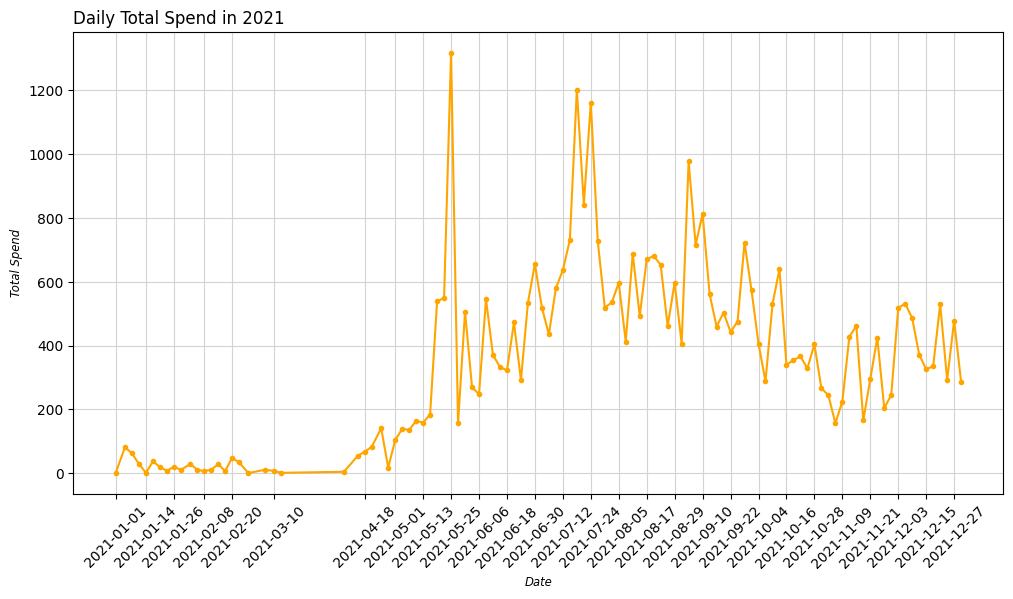

In [8]:
#графік з щоденною сумою витрат на рекламу в 2021 році
sampled_data = grouped_2021.iloc[::3]
plt.figure(figsize=(12, 6))
plt.plot(sampled_data['ad_date'], sampled_data['total_spend'], color = 'orange', marker = '.')
plt.rcParams['figure.facecolor'] = 'lightgrey'
plt.rcParams['axes.facecolor'] = 'white'
plt.xticks(sampled_data['ad_date'][::4], rotation=45)
plt.xlabel('Date', fontsize = 'small', fontstyle = 'italic')
plt.ylabel('Total Spend',fontsize = 'small', fontstyle = 'italic')
plt.title('Daily Total Spend in 2021',fontsize='large', loc='left')
plt.grid(True, color='lightgray')

In [9]:
#групую ROMI за 2021 рік
grouped_2021_romi = year_2021.groupby('ad_date')['romi'].sum().reset_index()
print(grouped_2021_romi.head(20))

      ad_date      romi
0  2021-01-01  1.512821
1  2021-01-02  0.891473
2  2021-01-04  0.977305
3  2021-01-05  0.760074
4  2021-01-06  2.022425
5  2021-01-07  3.085421
6  2021-01-08  2.818839
7  2021-01-09  0.763379
8  2021-01-10  0.944048
9  2021-01-11  1.139845
10 2021-01-12  2.683999
11 2021-01-13  2.188349
12 2021-01-14  1.055556
13 2021-01-15  3.272423
14 2021-01-16  2.468727
15 2021-01-17  1.584561
16 2021-01-18  2.048932
17 2021-01-19  2.845536
18 2021-01-20  2.854156
19 2021-01-21  2.937961


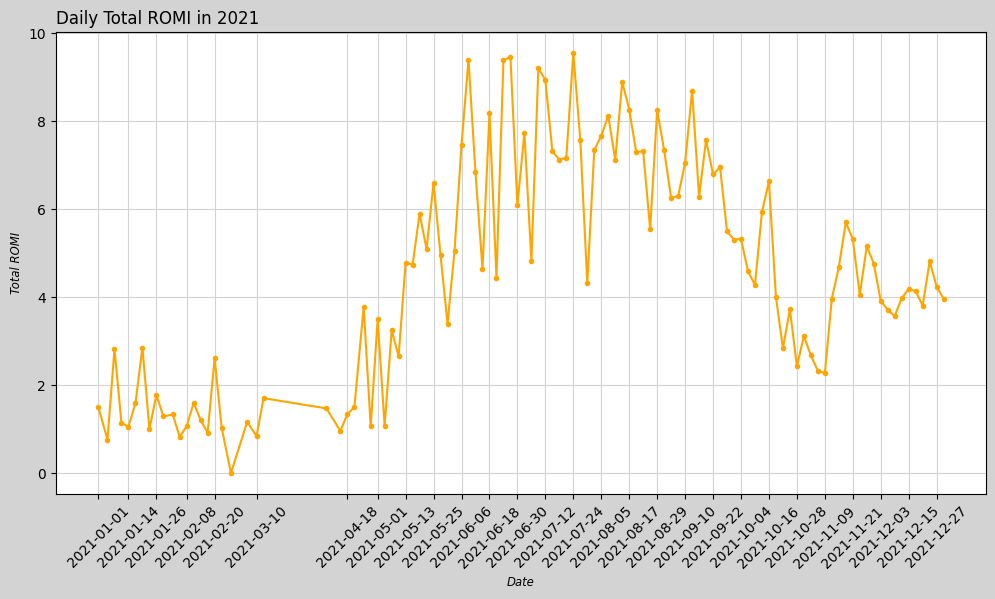

In [10]:
# графік з щоденним ROMI в 2021 році
sampled_romi = grouped_2021_romi.iloc[::3]
plt.figure(figsize=(12, 6))
plt.plot(sampled_romi['ad_date'], sampled_romi['romi'], color = 'orange', marker = '.')
plt.rcParams['figure.facecolor'] = 'lightgrey'
plt.rcParams['axes.facecolor'] = 'white'
plt.xticks(sampled_romi['ad_date'][::4], rotation=45)
plt.xlabel('Date', fontsize = 'small', fontstyle = 'italic')
plt.ylabel('Total ROMI',fontsize = 'small', fontstyle = 'italic')
plt.title('Daily Total ROMI in 2021',fontsize='large', loc='left')
plt.grid(True, color='lightgray')

Бонусне завдання: застосуй метод rolling() щоб відобразити рухоме середнє витрат та ROMI

In [11]:
#застосовую метод rolling для відображення рухомого середнього витрат
grouped_2021['spend_2021_rolling'] = grouped_2021['total_spend'].rolling(30).mean()

In [12]:
#застосовую метод rolling для відображення рухомого середнього ROMI
grouped_2021_romi['rolling_romi'] = grouped_2021_romi['romi'].rolling(30).mean()

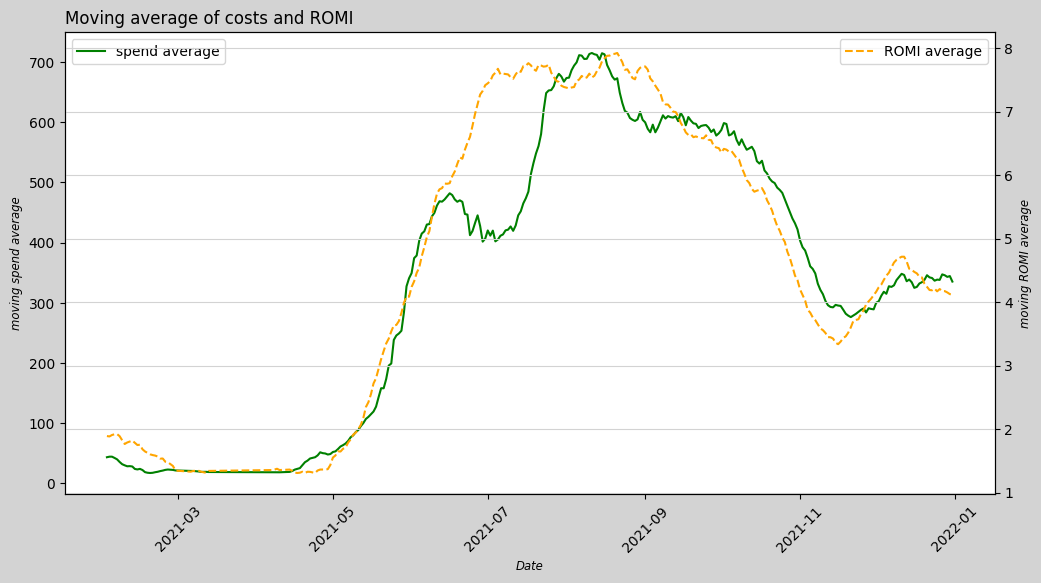

In [13]:
#графік, що відображає рухоме середнє витрат та ROMI
plt.figure(figsize=(12,6))
plt.xticks(rotation=45)
plt.plot(grouped_2021['ad_date'],grouped_2021['spend_2021_rolling'], color = 'green', label='spend average',linestyle='-')
ax = plt.gca()
ax2 = ax.twinx()
ax2.plot(grouped_2021_romi['ad_date'],grouped_2021_romi['rolling_romi'], color = 'orange',label='ROMI average',linestyle='--')
ax.set_xlabel('Date', fontsize = 'small', fontstyle = 'italic')
ax.set_ylabel('moving spend average',fontsize = 'small', fontstyle = 'italic')
ax2.set_ylabel('moving ROMI average',fontsize = 'small', fontstyle = 'italic')
plt.title('Moving average of costs and ROMI',fontsize='large', loc='left')
ax.legend(loc = 'upper left')
ax2.legend(loc = 'upper right')
plt.grid(True, color='lightgray')


Зроби групування даних за назвою кампанії побудуй два графіки:

Графік загальної суми витрат на рекламу в кожній з кампаній;
Загальний ROMI в кожній з кампаній.

In [14]:
#роблю групування загальних витрат за назвою кампанії
group_campaign = ads.groupby('campaign_name')['total_spend'].sum().reset_index()

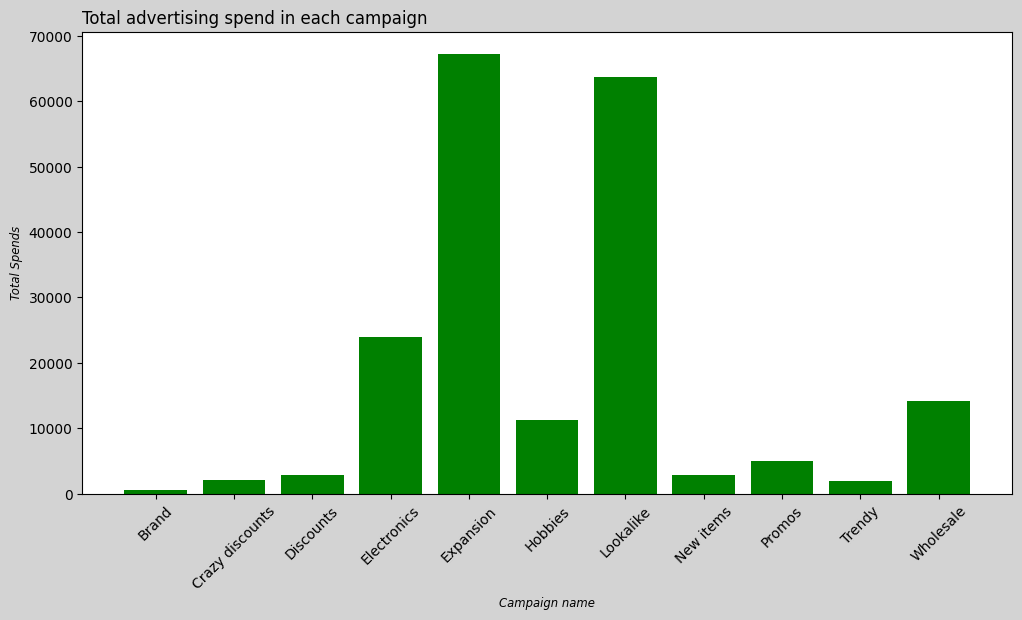

In [15]:
#графік загальної суми витрат на рекламу в кожній з кампаній
plt.figure(figsize=(12,6))
plt.xticks(rotation=45)
plt.bar(group_campaign['campaign_name'],group_campaign['total_spend'],color='green')
plt.xlabel('Campaign name', fontsize = 'small', fontstyle = 'italic')
plt.ylabel('Total Spends',fontsize = 'small', fontstyle = 'italic')
plt.grid(color='lightgray')
plt.title('Total advertising spend in each campaign',fontsize='large', loc='left')
plt.grid(False)

In [16]:
#роблю групування ROMI за назвою кампанії
romi_campaign = ads.groupby('campaign_name')['romi'].sum().reset_index()

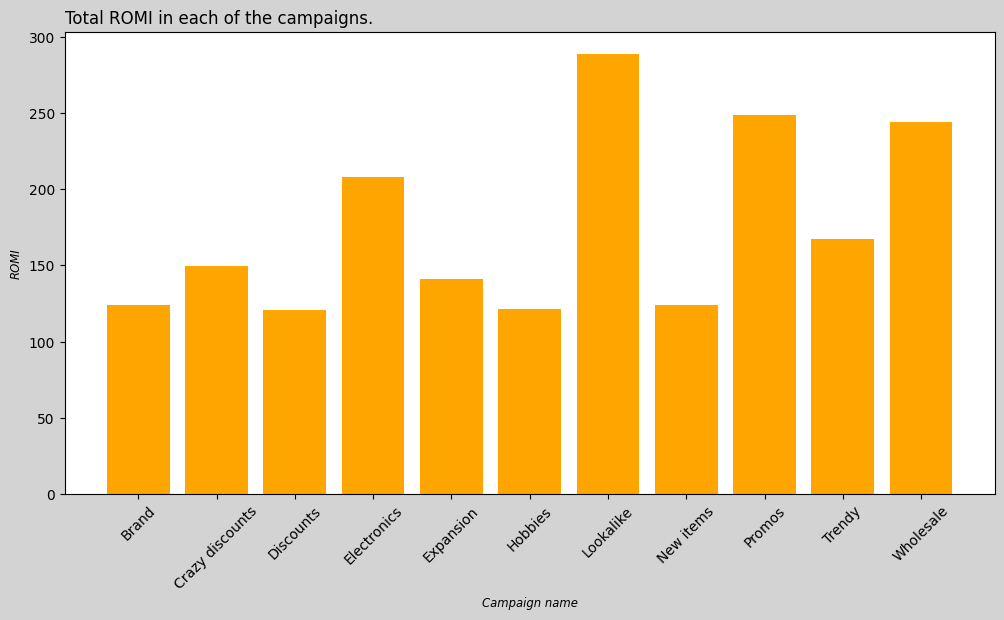

In [17]:
#графік, що показує загальний ROMI в кожній з кампаній
plt.figure(figsize=(12,6))
plt.xticks(rotation=45)
plt.bar(romi_campaign['campaign_name'],romi_campaign['romi'],color='orange')
plt.xlabel('Campaign name', fontsize = 'small', fontstyle = 'italic')
plt.ylabel('ROMI',fontsize = 'small', fontstyle = 'italic')
plt.grid(color='lightgray')
plt.title('Total ROMI in each of the campaigns.',fontsize='large', loc='left')
plt.grid(False)

За допомогою box plot визнач, яким був розкид щоденного ROMI в кожній кампаній (за назвою кампанії.)

Text(0, 0.5, 'ROMI')

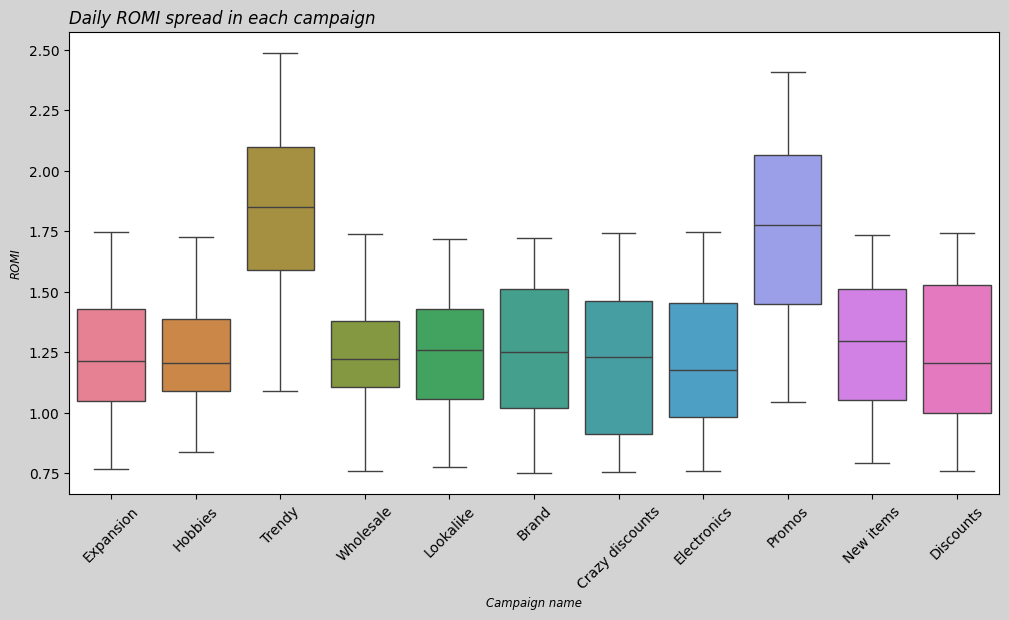

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=ads,x='campaign_name',y='romi', hue='campaign_name')
plt.xticks(rotation=45)
plt.title('Daily ROMI spread in each campaign',fontsize = 'large', fontstyle = 'italic',loc='left')
plt.xlabel('Campaign name',fontsize = 'small', fontstyle = 'italic')
plt.ylabel('ROMI',fontsize = 'small', fontstyle = 'italic')

Побудуй гістограму з розподілом значень ROMI в таблиці facebook_ads_data.csv

Text(5.069444444444445, 0.5, 'Frequency')

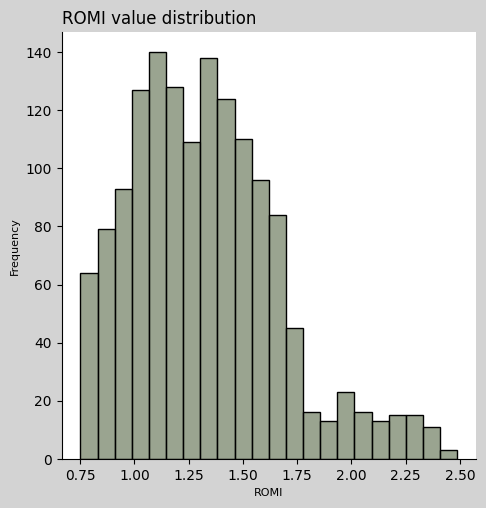

In [19]:
sns.displot(data=ads,x='romi', color= '#78866b')
plt.title('ROMI value distribution', fontsize=12, loc='left')
plt.xlabel('ROMI', fontsize=8)
plt.ylabel('Frequency', fontsize=8)

 Побудуй теплову карту кореляції між усіма числовими показниками в таблиці facebook_ads_data.csv. Які показники мають найвищу та найнижчу кореляцію? З чим корелює "total_value"?

In [30]:
#створюю датафрейм з усіма числовими показниками з таблиці facebook_ads_data
columns_num = ['total_spend', 'total_impressions', 'total_clicks', 'total_value', 'cpc', 'cpm', 'ctr', 'romi']
#обчислюю кореляцію для всіх числових значень
correlations = ads[columns_num].corr()


From the heat map you can see:
 Correlation values ​​from -1 to 1:
 1 - full positive correlation.
 0 - no correlation.
 -1 - full negative correlation.


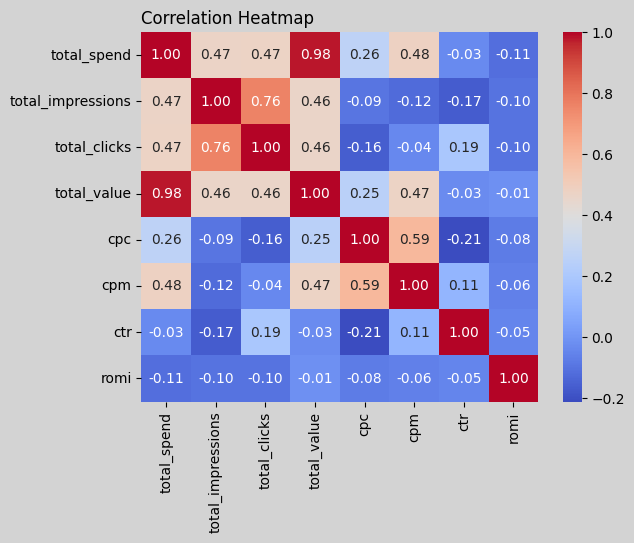

In [31]:
#будую теплову карту для визначення найвищої та найнижчої кореляції
sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap', loc='left')
print(f'From the heat map you can see:\n Correlation values ​​from -1 to 1:\n 1 - full positive correlation.\n 0 - no correlation.\n -1 - full negative correlation.')

In [27]:
#визначаю з чим корелюють значення захального доходу
total_value_corr = correlations['total_value']
print(total_value_corr.sort_values(ascending=False))

total_value          1.000000
total_spend          0.978615
cpm                  0.471471
total_clicks         0.464695
total_impressions    0.463626
cpc                  0.250851
romi                -0.012599
ctr                 -0.029720
Name: total_value, dtype: float64


Побудуй точкову діаграму з лінійною регресією (для цього ти можеш використати функцію lmplot()), що побудована на даних з "total_spend" та "total_value" щоб візуалізувати звʼязок між цими величинами.

Text(0.0, 1.0, 'Linear regression')

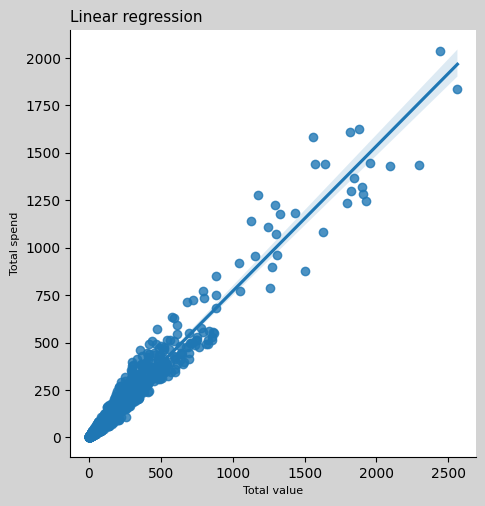

In [23]:
sns.lmplot(data = ads, x='total_value',y='total_spend')
plt.xlabel('Total value', fontsize=8)
plt.ylabel('Total spend', fontsize=8)
plt.title('Linear regression',fontsize=11,loc='left')